# Exploratory Data Analysis (EDA)
## Multilingual Health Question Answering in Low-Resource African Languages

This notebook performs a comprehensive exploratory analysis of the dataset before any modelling. The goal is to understand:
- Language and subset distribution
- Question and answer length statistics
- Vocabulary and token characteristics
- Data quality and missing values
- Multilingual text characteristics

## 1 — Install and Import

In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn
print('✅ Packages installed')

✅ Packages installed


In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_theme(style='whitegrid')

SEED = 42
print('✅ Imports done')

✅ Imports done


## 2 — Load Data

In [3]:
DATA_DIR = Path('/content')

train = pd.read_csv(DATA_DIR / 'Train.csv')
test  = pd.read_csv(DATA_DIR / 'Test.csv')
val   = pd.read_csv(DATA_DIR / 'Val.csv')

print(f'Train shape : {train.shape}')
print(f'Val shape   : {val.shape}')
print(f'Test shape  : {test.shape}')

print('\nTrain columns:', train.columns.tolist())
print('Test columns :', test.columns.tolist())
display(train.head(3))

Train shape : (29815, 4)
Val shape   : (6686, 4)
Test shape  : (2618, 3)

Train columns: ['ID', 'input', 'output', 'subset']
Test columns : ['ID', 'input', 'subset']


,ID,input,output,subset
0,ID_TR_Aka_Gha_A3B1799D,Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a...,Mmabun betumi aboa atipɛnfo a ebia nsa anaa nn...,Aka_Gha
1,ID_TR_Aka_Gha_1C80317F,Edinnsiananmu bɛn na nnipa a ɛsono wɔn bɔbeasu...,"Wɔ Ghana mu no, amanmmra no gye binary gender ...",Aka_Gha
2,ID_TR_Aka_Gha_06671AD1,Ɔkwan bɛn so na ɔbarima ne ɔbea nna a wɔtwe wɔ...,Sɛ wɔtwe wɔn ho fi nna mu anaasɛ wɔtwentwɛn wɔ...,Aka_Gha


## 3 — Missing Values and Data Quality

In [4]:
print('=== Missing Values ===')
print('\nTrain:')
print(train.isnull().sum())
print('\nVal:')
print(val.isnull().sum())
print('\nTest:')
print(test.isnull().sum())

print('\n=== Duplicate Questions ===')
print(f'Train duplicate questions : {train["input"].duplicated().sum()}')
print(f'Val duplicate questions   : {val["input"].duplicated().sum()}')

=== Missing Values ===

Train:
ID        0
input     0
output    0
subset    0
dtype: int64

Val:
ID        0
input     0
output    0
subset    0
dtype: int64

Test:
ID        0
input     0
subset    0
dtype: int64

=== Duplicate Questions ===
Train duplicate questions : 1469
Val duplicate questions   : 92


## 4 — Language Distribution

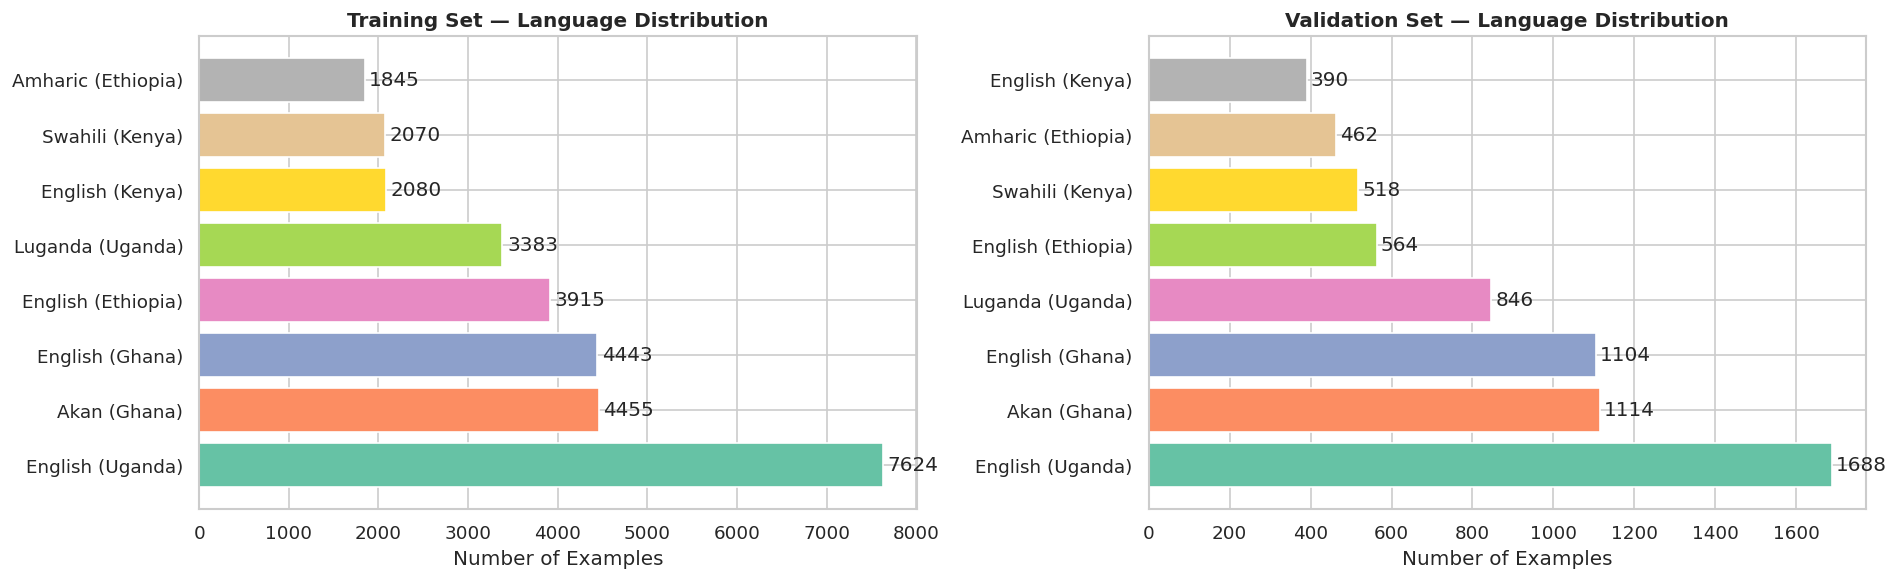


Train language distribution:


,count,pct
language,,
English (Uganda),7624,25.6
Akan (Ghana),4455,14.9
English (Ghana),4443,14.9
English (Ethiopia),3915,13.1
Luganda (Uganda),3383,11.3
English (Kenya),2080,7.0
Swahili (Kenya),2070,6.9
Amharic (Ethiopia),1845,6.2


In [5]:
SUBSET_TO_LANGUAGE = {
    'Aka_Gha': 'Akan (Ghana)',
    'Amh_Eth': 'Amharic (Ethiopia)',
    'Eng_Eth': 'English (Ethiopia)',
    'Eng_Gha': 'English (Ghana)',
    'Eng_Ken': 'English (Kenya)',
    'Eng_Uga': 'English (Uganda)',
    'Lug_Uga': 'Luganda (Uganda)',
    'Swa_Ken': 'Swahili (Kenya)',
}

train['language'] = train['subset'].map(SUBSET_TO_LANGUAGE)
val['language']   = val['subset'].map(SUBSET_TO_LANGUAGE)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Train distribution
train_counts = train['language'].value_counts()
axes[0].barh(train_counts.index, train_counts.values, color=sns.color_palette('Set2', len(train_counts)))
axes[0].set_title('Training Set — Language Distribution', fontweight='bold')
axes[0].set_xlabel('Number of Examples')
for i, v in enumerate(train_counts.values):
    axes[0].text(v + 50, i, str(v), va='center')

# Val distribution
val_counts = val['language'].value_counts()
axes[1].barh(val_counts.index, val_counts.values, color=sns.color_palette('Set2', len(val_counts)))
axes[1].set_title('Validation Set — Language Distribution', fontweight='bold')
axes[1].set_xlabel('Number of Examples')
for i, v in enumerate(val_counts.values):
    axes[1].text(v + 10, i, str(v), va='center')

plt.tight_layout()
plt.savefig('/content/eda_language_distribution.png', bbox_inches='tight')
plt.show()

print('\nTrain language distribution:')
display(train_counts.to_frame('count').assign(pct=lambda x: (x['count']/x['count'].sum()*100).round(1)))

## 5 — Question Length Analysis

In [6]:
train['q_word_len'] = train['input'].str.split().str.len()
train['q_char_len'] = train['input'].str.len()
train['a_word_len'] = train['output'].str.split().str.len()
train['a_char_len'] = train['output'].str.len()

val['q_word_len'] = val['input'].str.split().str.len()
val['a_word_len'] = val['output'].str.split().str.len()

print('=== Question Length (words) ===')
print(train['q_word_len'].describe().round(1))
print('\n=== Answer Length (words) ===')
print(train['a_word_len'].describe().round(1))

=== Question Length (words) ===
count    29815.0
mean        15.1
std          9.1
min          0.0
25%          9.0
50%         13.0
75%         18.0
max         83.0
Name: q_word_len, dtype: float64

=== Answer Length (words) ===
count    29815.0
mean        76.2
std         58.9
min          1.0
25%         30.0
50%         61.0
75%        107.0
max        482.0
Name: a_word_len, dtype: float64


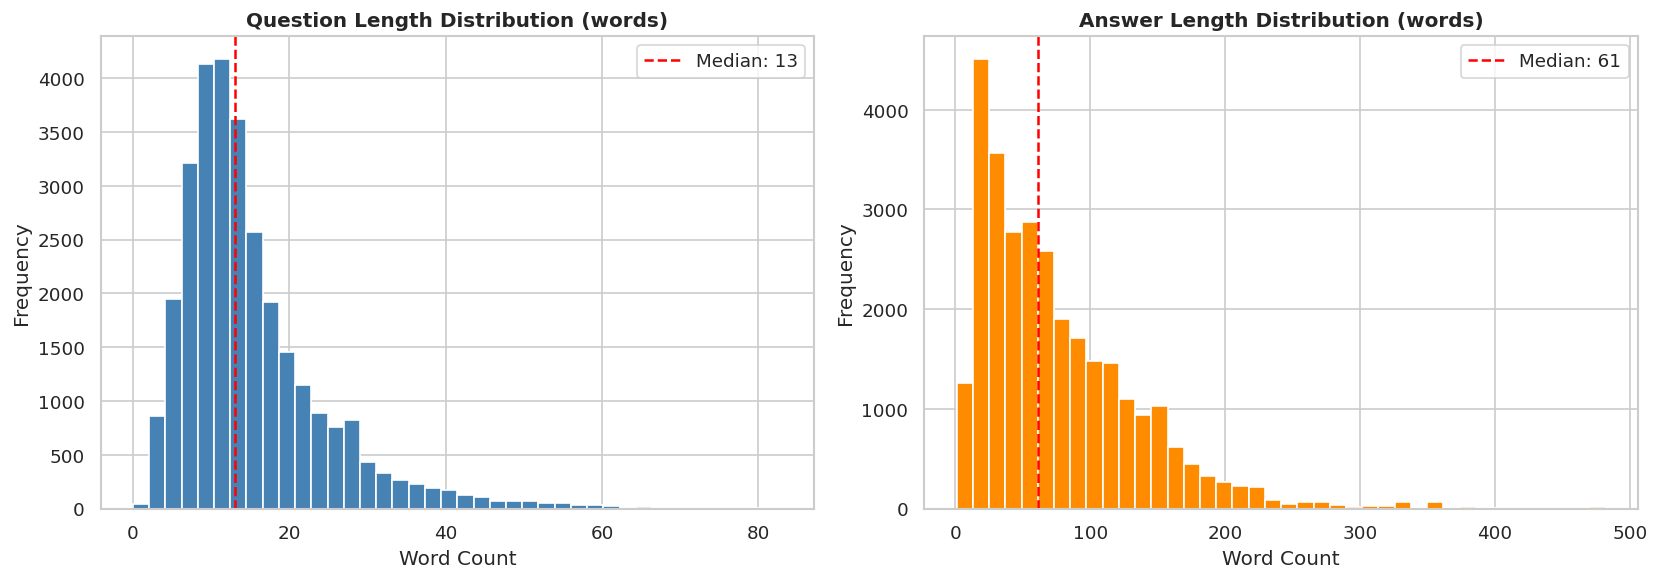

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train['q_word_len'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Question Length Distribution (words)', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(train['q_word_len'].median(), color='red', linestyle='--', label=f'Median: {train["q_word_len"].median():.0f}')
axes[0].legend()

axes[1].hist(train['a_word_len'], bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Answer Length Distribution (words)', fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(train['a_word_len'].median(), color='red', linestyle='--', label=f'Median: {train["a_word_len"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/eda_length_distribution.png', bbox_inches='tight')
plt.show()

## 6 — Length by Language

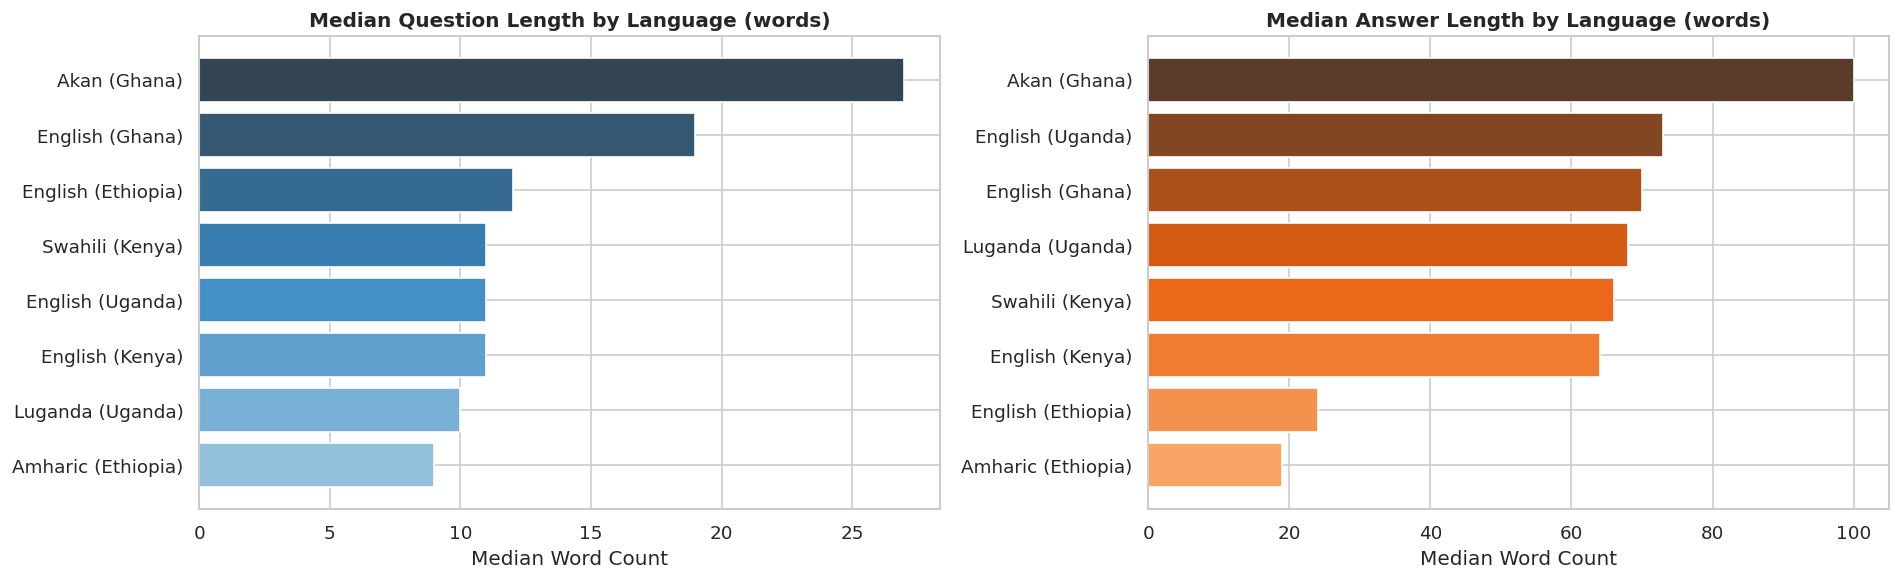

,count,q_mean_words,q_median_words,a_mean_words,a_median_words
language,,,,,
Akan (Ghana),4455,28.8,27.0,105.6,100.0
Amharic (Ethiopia),1845,9.5,9.0,20.2,19.0
English (Ethiopia),3915,12.2,12.0,24.5,24.0
English (Ghana),4443,20.0,19.0,75.1,70.0
English (Kenya),2080,11.4,11.0,78.7,64.0
English (Uganda),7624,11.2,11.0,95.4,73.0
Luganda (Uganda),3383,10.5,10.0,79.7,68.0
Swahili (Kenya),2070,11.2,11.0,84.3,66.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

lang_q = train.groupby('language')['q_word_len'].median().sort_values()
lang_a = train.groupby('language')['a_word_len'].median().sort_values()

axes[0].barh(lang_q.index, lang_q.values, color=sns.color_palette('Blues_d', len(lang_q)))
axes[0].set_title('Median Question Length by Language (words)', fontweight='bold')
axes[0].set_xlabel('Median Word Count')

axes[1].barh(lang_a.index, lang_a.values, color=sns.color_palette('Oranges_d', len(lang_a)))
axes[1].set_title('Median Answer Length by Language (words)', fontweight='bold')
axes[1].set_xlabel('Median Word Count')

plt.tight_layout()
plt.savefig('/content/eda_length_by_language.png', bbox_inches='tight')
plt.show()

# Summary table
summary = train.groupby('language').agg(
    count=('input', 'count'),
    q_mean_words=('q_word_len', 'mean'),
    q_median_words=('q_word_len', 'median'),
    a_mean_words=('a_word_len', 'mean'),
    a_median_words=('a_word_len', 'median'),
).round(1)
display(summary)

## 7 — Train / Val / Test Split Analysis

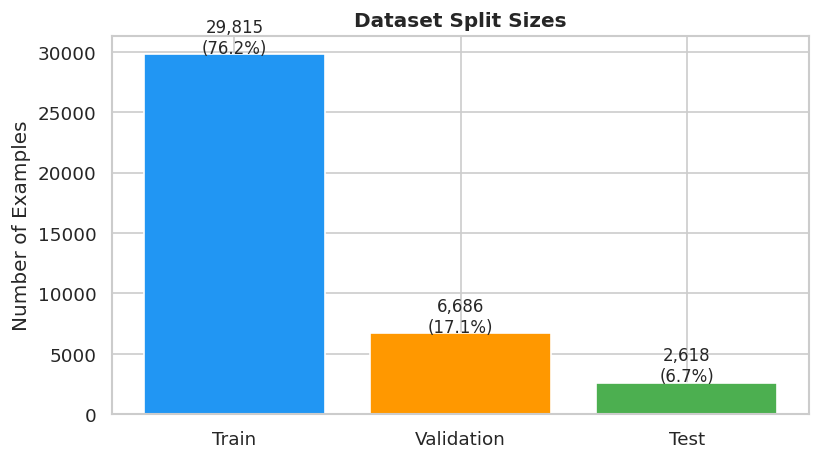

,Split,Examples,Percentage
0,Train,29815,76.2
1,Validation,6686,17.1
2,Test,2618,6.7


In [9]:
total = len(train) + len(val) + len(test)
splits = pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test'],
    'Examples': [len(train), len(val), len(test)],
    'Percentage': [len(train)/total*100, len(val)/total*100, len(test)/total*100]
})

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2196F3', '#FF9800', '#4CAF50']
bars = ax.bar(splits['Split'], splits['Examples'], color=colors)
ax.set_title('Dataset Split Sizes', fontweight='bold')
ax.set_ylabel('Number of Examples')
for bar, pct in zip(bars, splits['Percentage']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{bar.get_height():,}\n({pct:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('/content/eda_split_sizes.png', bbox_inches='tight')
plt.show()
display(splits.round(1))

## 8 — Language Balance in Train vs Val

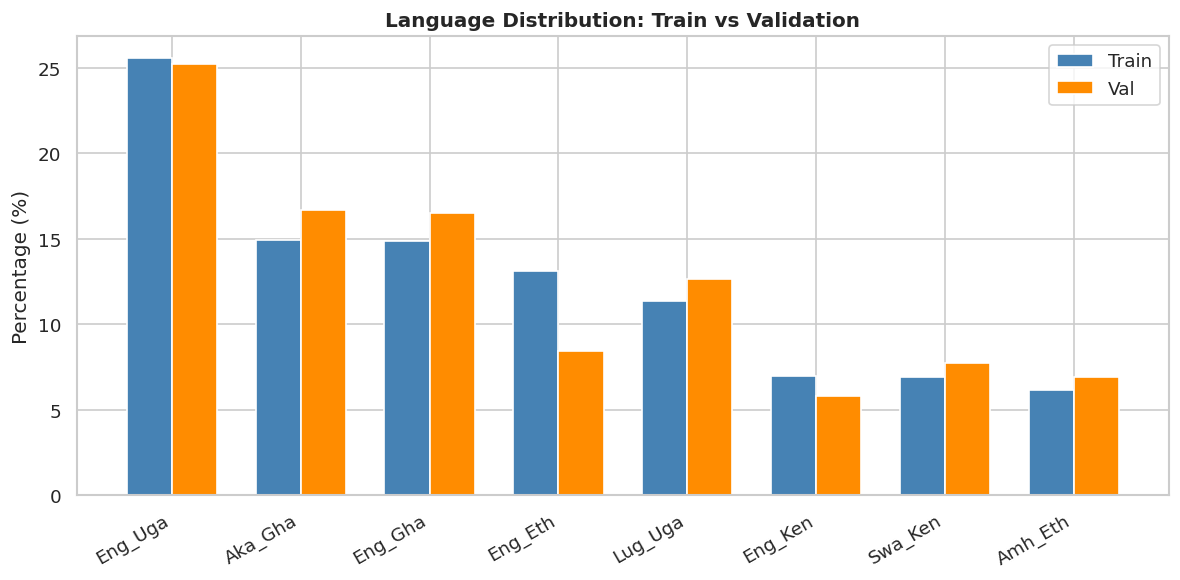

,Train %,Val %
subset,,
Eng_Uga,25.57,25.25
Aka_Gha,14.94,16.66
Eng_Gha,14.90,16.51
Eng_Eth,13.13,8.44
Lug_Uga,11.35,12.65
Eng_Ken,6.98,5.83
Swa_Ken,6.94,7.75
Amh_Eth,6.19,6.91


In [10]:
train_pct = (train['subset'].value_counts() / len(train) * 100).rename('Train %')
val_pct   = (val['subset'].value_counts() / len(val) * 100).rename('Val %')
balance   = pd.concat([train_pct, val_pct], axis=1).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(balance))
width = 0.35
ax.bar(x - width/2, balance['Train %'], width, label='Train', color='steelblue')
ax.bar(x + width/2, balance['Val %'],   width, label='Val',   color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(balance.index, rotation=30, ha='right')
ax.set_ylabel('Percentage (%)')
ax.set_title('Language Distribution: Train vs Validation', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('/content/eda_train_val_balance.png', bbox_inches='tight')
plt.show()
display(balance)

## 9 — Sample Questions per Language

In [11]:
print('Sample questions and answers per language subset:\n')
for subset in sorted(train['subset'].unique()):
    sample = train[train['subset'] == subset].iloc[0]
    print(f'[{subset}]')
    print(f'  Q: {sample["input"][:150]}')
    print(f'  A: {sample["output"][:150]}')
    print()

Sample questions and answers per language subset:

[Aka_Gha]
  Q: Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye wɔn werɛ, sɛnea wɔbɛboa wɔn ma wɔan
  A: Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na wɔagye wɔn nkate atom a wɔremmu atɛ

[Amh_Eth]
  Q: የረጅም ጊዜ ጤናን በተመለከተ በጣም ሊያሳስበኝ የሚገቡ ሶስት ዋና ዋና ኢንፌክሽኖች የትኞቹ ናቸው?
  A: ኤች አይ ቪ፣ ሄፓታይተስ ቢ እና ሂውማን ፓፒሎማ ቫይረስ (HPV)ናቸው።

[Eng_Eth]
  Q: How is syphilis diagnosed?
  A: Blood tests like VDRL and RPR confirm syphilis infection.

[Eng_Gha]
  Q: What should I do if I have unprotected sex or experience a contraceptive failure?
  A: If you have unprotected sex or experience contraceptive failure, consider the following steps: - Take emergency contraception if appropriate and avail

[Eng_Ken]
  Q: How can society ensure that HIV patients are incorporated in it?
  A: Incorporating HIV patients into society is essentia

## 10 — Key EDA Insights

**Summary of findings:**

1. **Class imbalance**: English subsets (Eng_Ken, Eng_Uga, Eng_Eth, Eng_Gha) together make up the majority of training examples. Akan (Aka_Gha) and Amharic (Amh_Eth) have fewer examples, making them low-resource subsets within the dataset.

2. **Answer length**: Answers are significantly longer than questions on average. This confirms the task is open-ended generation rather than span extraction.

3. **Language diversity**: The dataset covers 5 distinct languages across 4 African countries, with significant script diversity (Latin for English/Akan/Luganda/Swahili, Ge'ez for Amharic). This makes character-level features important for TF-IDF.

4. **Train/Val balance**: The stratified split ensures language proportions are consistent between train and validation sets.

5. **No missing values**: The dataset is clean with no null values in the key columns.

6. **Preprocessing implication**: Whitespace tokenization (rather than language-specific tokenizers) was chosen for ROUGE evaluation to remain language-agnostic across all 5 languages.